ADVANCED MARKET BASKET ANALYSIS SYSTEM

Total transactions: 10

Binary Transaction Matrix
   Bread  Butter  Cereal   Eggs    Jam   Milk
0   True   False   False   True  False   True
1   True    True   False  False   True  False
2   True    True   False  False  False   True
3   True    True   False   True  False   True
4  False   False    True   True  False   True

BASIC STATISTICS

Item Frequencies:
Bread     8
Milk      8
Butter    6
Eggs      5
Jam       3
Cereal    2
dtype: int64

Average items per transaction: 3.2

APRIORI RESULTS

Frequent Itemsets:
    support               itemsets
0       0.8                (Bread)
1       0.6               (Butter)
2       0.5                 (Eggs)
3       0.3                  (Jam)
4       0.8                 (Milk)
5       0.6        (Butter, Bread)
6       0.3          (Eggs, Bread)
7       0.3           (Jam, Bread)
8       0.6          (Milk, Bread)
9       0.3          (Butter, Jam)
10      0.4         (Butter, Milk)
11      0.5        

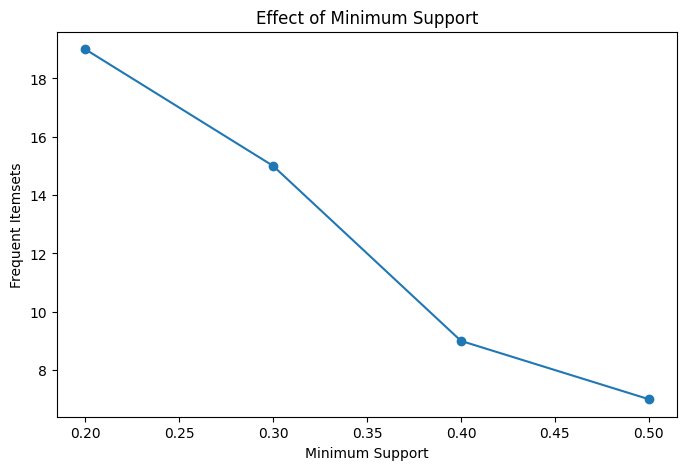


RULE PRUNING

Pruned Rules:
       antecedents      consequents  confidence      lift
0         (Butter)          (Bread)       1.000  1.250000
1          (Bread)         (Butter)       0.750  1.250000
2            (Jam)          (Bread)       1.000  1.250000
5            (Jam)         (Butter)       1.000  1.666667
6           (Eggs)           (Milk)       1.000  1.250000
7           (Milk)           (Eggs)       0.625  1.250000
8    (Butter, Jam)          (Bread)       1.000  1.250000
10    (Bread, Jam)         (Butter)       1.000  1.666667
12           (Jam)  (Butter, Bread)       1.000  1.666667
14  (Butter, Milk)          (Bread)       1.000  1.250000
18   (Eggs, Bread)           (Milk)       1.000  1.250000

Rules after removing redundancy: 6

TOP RULES
1 . Bread, Jam -> Butter
Support: 0.3 Confidence: 1.0 Lift: 1.67
2 . Jam -> Butter, Bread
Support: 0.3 Confidence: 1.0 Lift: 1.67
3 . Milk -> Eggs
Support: 0.5 Confidence: 0.62 Lift: 1.25
4 . Butter, Jam -> Bread
Support: 0.3 Co

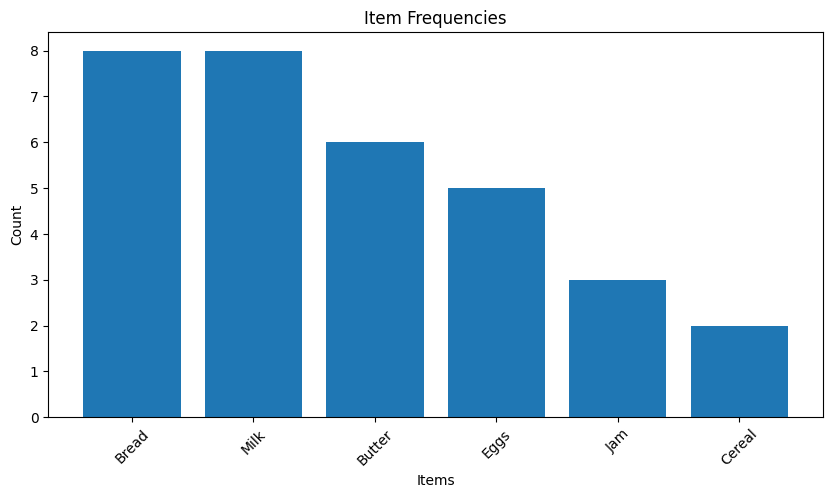

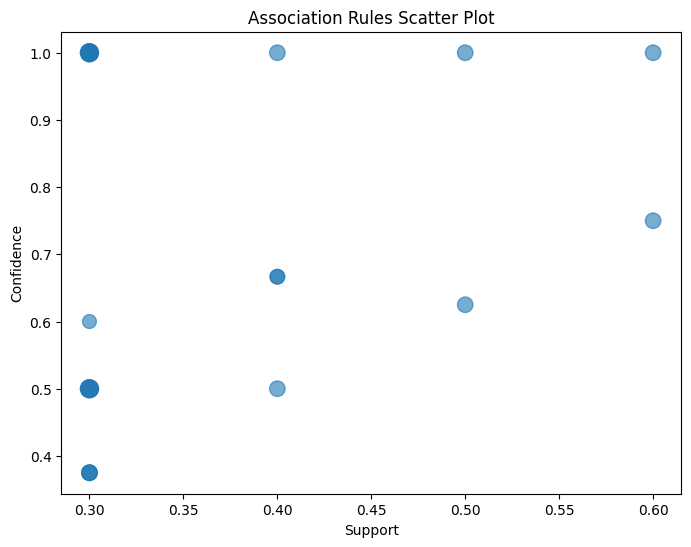

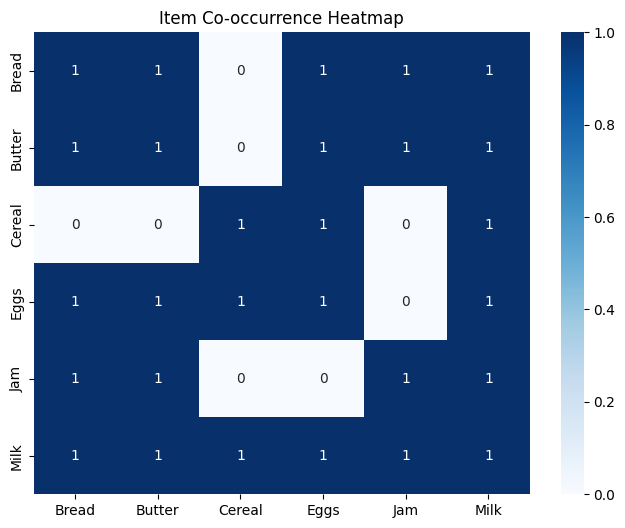

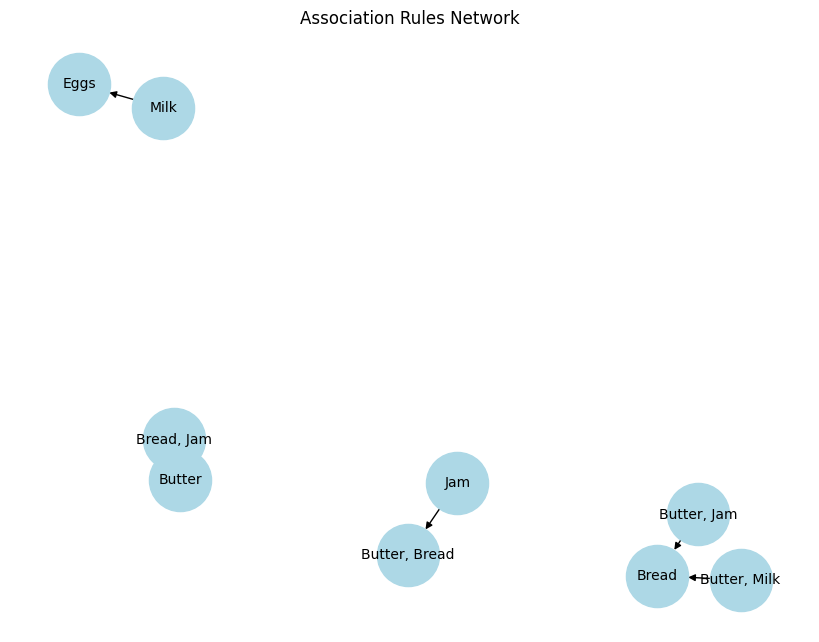


MULTI-DOMAIN ASSOCIATION RULE MINING

Online Shopping Rules
  antecedents consequents  confidence      lift
0    (Laptop)     (Mouse)         1.0  1.666667
1     (Mouse)    (Laptop)         1.0  1.666667

Medical Association Rules
  antecedents consequents  confidence      lift
0     (Cough)      (Cold)    0.666667  1.111111
1      (Cold)     (Cough)    0.666667  1.111111
2     (Cough)     (Fever)    0.666667  1.111111
3     (Fever)     (Cough)    0.666667  1.111111

BUSINESS INSIGHTS

Strongest Rule: Bread, Jam -> Butter
Lift: 1.67

Marketing Strategies
1. Place associated items close in store
2. Create combo offers
3. Cross sell related items
4. Build themed product sections

Results saved to association_rules.csv

Program Completed Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import time
import warnings

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

warnings.filterwarnings('ignore')

print("="*70)
print("ADVANCED MARKET BASKET ANALYSIS SYSTEM")
print("="*70)

# ---------------------------------------------------
# PART 1 : DATA PREPARATION
# ---------------------------------------------------

transactions = [
    ['Bread','Milk','Eggs'],
    ['Bread','Butter','Jam'],
    ['Milk','Bread','Butter'],
    ['Bread','Milk','Butter','Eggs'],
    ['Milk','Eggs','Cereal'],
    ['Bread','Eggs','Milk'],
    ['Butter','Jam','Bread'],
    ['Bread','Milk','Butter'],
    ['Milk','Cereal','Eggs'],
    ['Bread','Butter','Jam','Milk']
]

print("\nTotal transactions:", len(transactions))

te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_data, columns=te.columns_)

print("\nBinary Transaction Matrix")
print(df.head())

# ---------------------------------------------------
# PART 2 : BASIC STATISTICS
# ---------------------------------------------------

print("\n"+"="*70)
print("BASIC STATISTICS")
print("="*70)

item_freq = df.sum().sort_values(ascending=False)
print("\nItem Frequencies:")
print(item_freq)

lengths = [len(t) for t in transactions]
print("\nAverage items per transaction:", round(np.mean(lengths),2))

# ---------------------------------------------------
# PART 3 : APRIORI ALGORITHM
# ---------------------------------------------------

print("\n"+"="*70)
print("APRIORI RESULTS")
print("="*70)

min_support = 0.3

start = time.time()
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
apriori_time = time.time() - start

print("\nFrequent Itemsets:")
print(frequent_itemsets)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print("\nAssociation Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']])

# ---------------------------------------------------
# PART 4 : FP-GROWTH ALGORITHM
# ---------------------------------------------------

print("\n"+"="*70)
print("FP-GROWTH RESULTS")
print("="*70)

start = time.time()
fp_itemsets = fpgrowth(df, min_support=min_support, use_colnames=True)
fp_time = time.time() - start

print("\nFP-Growth Itemsets:")
print(fp_itemsets)

print("\nPerformance Comparison")
print("Apriori Time:", round(apriori_time,4),"seconds")
print("FP-Growth Time:", round(fp_time,4),"seconds")

# ---------------------------------------------------
# PART 5 : SUPPORT THRESHOLD ANALYSIS
# ---------------------------------------------------

print("\n"+"="*70)
print("SUPPORT THRESHOLD ANALYSIS")
print("="*70)

supports = [0.2,0.3,0.4,0.5]
counts = []

for s in supports:
    fi = apriori(df, min_support=s, use_colnames=True)
    counts.append(len(fi))
    print("Support",s,"->",len(fi),"itemsets")

plt.figure(figsize=(8,5))
plt.plot(supports,counts,marker='o')
plt.title("Effect of Minimum Support")
plt.xlabel("Minimum Support")
plt.ylabel("Frequent Itemsets")
plt.show()

# ---------------------------------------------------
# PART 6 : RULE PRUNING
# ---------------------------------------------------

print("\n"+"="*70)
print("RULE PRUNING")
print("="*70)

pruned_rules = rules[(rules['confidence']>=0.6) & (rules['lift']>1.2)]

print("\nPruned Rules:")
print(pruned_rules[['antecedents','consequents','confidence','lift']])

# Remove redundant rules
def remove_redundant(rules):
    unique = []
    for i,r1 in rules.iterrows():
        redundant = False
        for j,r2 in rules.iterrows():
            if i!=j:
                if set(r1['antecedents']).issubset(set(r2['antecedents'])) and \
                   set(r1['consequents']).issubset(set(r2['consequents'])):
                    redundant=True
        if not redundant:
            unique.append(r1)
    return pd.DataFrame(unique)

rules_clean = remove_redundant(pruned_rules)

print("\nRules after removing redundancy:",len(rules_clean))

# ---------------------------------------------------
# PART 7 : TOP RULES
# ---------------------------------------------------

print("\n"+"="*70)
print("TOP RULES")
print("="*70)

top_rules = rules_clean.nlargest(5,'lift')

for i,(idx,row) in enumerate(top_rules.iterrows(),1):

    a = ', '.join(list(row['antecedents']))
    c = ', '.join(list(row['consequents']))

    print(i,".",a,"->",c)
    print("Support:",round(row['support'],2),
          "Confidence:",round(row['confidence'],2),
          "Lift:",round(row['lift'],2))

# ---------------------------------------------------
# PART 8 : VISUALIZATIONS
# ---------------------------------------------------

print("\nGenerating Visualizations...")

# Item frequency bar chart
plt.figure(figsize=(10,5))
plt.bar(item_freq.index,item_freq.values)
plt.title("Item Frequencies")
plt.xlabel("Items")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(rules['support'],rules['confidence'],
            s=rules['lift']*100,alpha=0.6)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules Scatter Plot")
plt.show()

# Heatmap
co_matrix = np.dot(df.T,df)
co_df = pd.DataFrame(co_matrix,index=df.columns,columns=df.columns)

plt.figure(figsize=(8,6))
sns.heatmap(co_df,annot=True,cmap="Blues")
plt.title("Item Co-occurrence Heatmap")
plt.show()

# Network graph
if len(top_rules)>0:

    plt.figure(figsize=(8,6))

    G = nx.DiGraph()

    for idx,row in top_rules.iterrows():

        a = ', '.join(list(row['antecedents']))
        c = ', '.join(list(row['consequents']))

        G.add_edge(a,c,weight=row['lift'])

    pos = nx.spring_layout(G)

    nx.draw(G,pos,
            with_labels=True,
            node_color='lightblue',
            node_size=2000,
            font_size=10,
            arrows=True)

    plt.title("Association Rules Network")
    plt.show()

# ---------------------------------------------------
# PART 9 : MULTI DOMAIN APPLICATIONS
# ---------------------------------------------------

print("\n"+"="*70)
print("MULTI-DOMAIN ASSOCIATION RULE MINING")
print("="*70)

# Example 1 : Online Shopping
online = [
['Laptop','Mouse','Keyboard'],
['Phone','Headphones'],
['Laptop','Mouse'],
['Phone','Charger','Case'],
['Laptop','Bag','Mouse']
]

te = TransactionEncoder()
data = te.fit(online).transform(online)

df_online = pd.DataFrame(data,columns=te.columns_)

fi_online = apriori(df_online,min_support=0.4,use_colnames=True)
rules_online = association_rules(fi_online,metric="confidence",min_threshold=0.5)

print("\nOnline Shopping Rules")
print(rules_online[['antecedents','consequents','confidence','lift']])

# Example 2 : Medical Symptoms
medical = [
['Fever','Cough','Cold'],
['Fever','Headache'],
['Cough','Cold'],
['Fever','Cough'],
['Cold','Headache']
]

te = TransactionEncoder()
data = te.fit(medical).transform(medical)

df_med = pd.DataFrame(data,columns=te.columns_)

fi_med = apriori(df_med,min_support=0.4,use_colnames=True)
rules_med = association_rules(fi_med,metric="confidence",min_threshold=0.5)

print("\nMedical Association Rules")
print(rules_med[['antecedents','consequents','confidence','lift']])

# ---------------------------------------------------
# PART 10 : BUSINESS INTERPRETATION
# ---------------------------------------------------

print("\n"+"="*70)
print("BUSINESS INSIGHTS")
print("="*70)

if len(top_rules)>0:

    best = top_rules.iloc[0]

    a = ', '.join(list(best['antecedents']))
    c = ', '.join(list(best['consequents']))

    print("\nStrongest Rule:",a,"->",c)
    print("Lift:",round(best['lift'],2))

print("\nMarketing Strategies")
print("1. Place associated items close in store")
print("2. Create combo offers")
print("3. Cross sell related items")
print("4. Build themed product sections")

# ---------------------------------------------------
# SAVE RESULTS
# ---------------------------------------------------

rules[['antecedents','consequents','support','confidence','lift']].to_csv("association_rules.csv",index=False)

print("\nResults saved to association_rules.csv")
print("\nProgram Completed Successfully")